# 1. Setup and Load Data

### 1.1 install dependencies

In [1]:
#!pip install tensorflow opencv-python matplotlib

In [2]:
pip list

Package                 Version
----------------------- -----------
absl-py                 2.3.1
asttokens               3.0.0
astunparse              1.6.3
certifi                 2025.10.5
charset-normalizer      3.4.4
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
executing               2.2.1
flatbuffers             25.9.23
fonttools               4.60.1
gast                    0.6.0
google-pasta            0.2.0
grpcio                  1.76.0
h5py                    3.15.1
idna                    3.11
ipykernel               7.0.1
ipython                 9.6.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.6.3
jupyter_core            5.9.1
keras                   3.11.3
kiwisolver              1.4.9
libclang                18.1.1
Markdown                3.9
markdown-it-py          4.0.0
MarkupSafe           

In [3]:
import tensorflow as tf
import os

### 1.2 Remove some images

In [4]:
import cv2 as cv

In [5]:
data_dir = 'data'

In [6]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png']

In [7]:
os.listdir(os.path.join('data','happy'))

['-41604787097oijary3e0b.png',
 '-cheerful-african-american-black-male-happy-expressive-smiley-face-197149245.jpg',
 '05-12-21-happy-people.jpg',
 '1-2.jpg',
 '1000_F_246149573_1dbnEopMZjSflWG4ZvojXhVVV8cTewTW.jpg',
 '1000_F_279669366_Lk12QalYQKMczLEa4ySjhaLtx1M2u7e6.jpg',
 '1000_F_42220133_toAU6USGY9jVr2XJFLssfG00cSYIJ173.jpg',
 '170404-happy-workers-feature.jpg',
 '1920px-face-smile.svg_.png',
 '1c9a7140a26d24e419f9aac492dc74d1.jpg',
 '1HEoLBLidT2u4mhJ0oiDgig.png',
 '1_617fd1e2590c2.jpg',
 '246365c4e7bd4439382590ef4a149e63.jpg',
 '35438_hd.jpg',
 '4586c3916fa6c536782ee7a168fe421c_large.jpg',
 '490dc6fee551ddd25c5075f01a8c454f.jpg',
 '5d7602eeb60b9-famous-paintings-portraits-faceapp-29-5d7246cf09c08__700.jpg',
 '613k1XcpYCL._SL1200_.jpg',
 '645Z474020copy.jpg',
 '7-Habits-of-Happy-People-image.jpeg',
 '7-principles-of-successful-and-happy-people.png',
 '71hBPTAhIXL.jpg',
 '932494e2b3e5e6c1bde09e22c71e2a02--natalie-portman-portrait-photography-tips.jpg',
 '960x0.jpg',
 '9784480213_26ce

In [8]:
for image_class in os.listdir(data_dir):
    print(image_class)

happy
sad


In [9]:
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)
    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)
        try:
            img = cv.imread(image_path)
            # If cv2.imread() fails, it returns None
            if img is None:
                print(f"Invalid image: {image_path}")
                os.remove(image_path)
                continue

            # Check the file extension manually
            ext = image.split('.')[-1].lower()
            if ext not in image_exts:
                print(f"Image not in extension list: {image_path}")
                os.remove(image_path)

        except Exception as e:
            print(f"Issue with image {image_path}: {e}")
            # os.remove(image_path)


### 1.3 Load Data

In [10]:
tf.data.Dataset??

Init signature: tf.data.Dataset(variant_tensor)
Source:        
@tf_export("data.Dataset", v1=[])
class DatasetV2(
    collections_abc.Iterable,
    tracking_base.Trackable,
    composite_tensor.CompositeTensor,
    data_types.DatasetV2,
    metaclass=abc.ABCMeta):
  """Represents a potentially large set of elements.

  The `tf.data.Dataset` API supports writing descriptive and efficient input
  pipelines. `Dataset` usage follows a common pattern:

  1. Create a source dataset from your input data.
  2. Apply dataset transformations to preprocess the data.
  3. Iterate over the dataset and process the elements.

  Iteration happens in a streaming fashion, so the full dataset does not need to
  fit into memory.

  Source Datasets:

  The simplest way to create a dataset is to create it from a python `list`:

  >>> dataset = tf.data.Dataset.from_tensor_slices([1, 2, 3])
  >>> for element in dataset:
  ...   print(element)
  tf.Tensor(1, shape=(), dtype=int32)
  tf.Tensor(2, shape=(), dty

In [11]:
import numpy as np
from matplotlib import pyplot as plt

In [12]:
tf.keras.utils.image_dataset_from_directory??
# this shows the documentation

Signature:
tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)
Source:   
@keras_export(
    [
        "keras.utils.image_dataset_from_directory",
        "keras.preprocessing.image_dataset_from_directory",
    ]
)
def image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    ve

In [13]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 1988 files belonging to 2 classes.


In [14]:
type(data)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [15]:
data_iterator = data.as_numpy_iterator()

In [16]:
batch = data_iterator.next()

In [17]:
# 2 parts of the data (images and labels)
len(batch)

2

In [18]:
# images represented as numpy arrays
batch[0].shape

(32, 256, 256, 3)

In [19]:
# Labels represented as numpy array
# class 1 : sad
# class 0 : happy
batch[1]

array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0], dtype=int32)

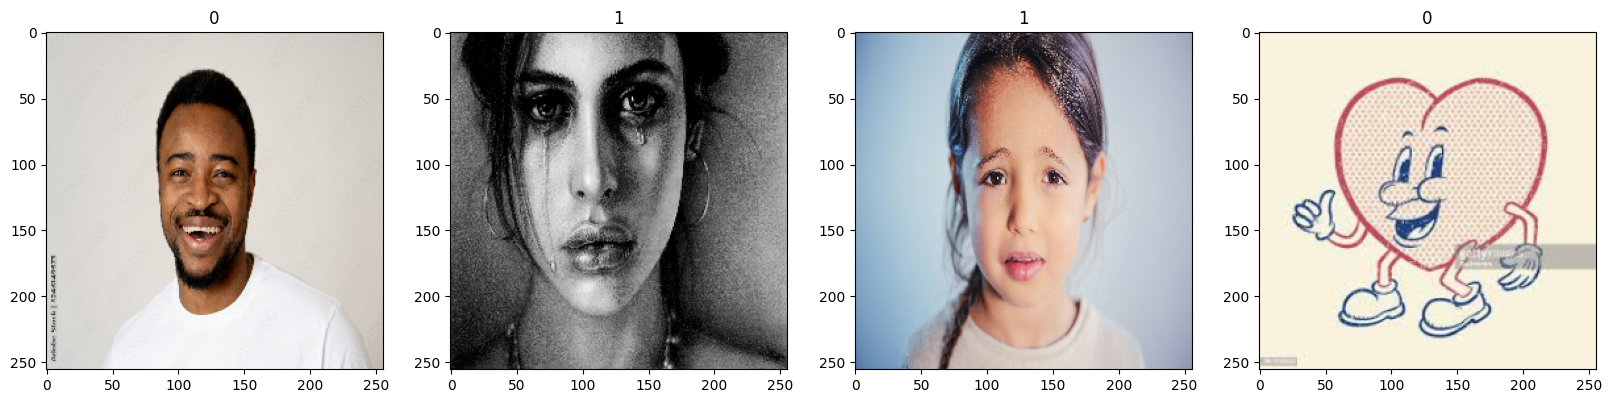

In [20]:
#plot the images

fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])  

# 2.0 Data Preprocessing

### 2.1 Data scaling

In [21]:
#0 - 255
scaled = batch[0]/255

In [22]:
scaled.min()

np.float32(0.0)

In [23]:
data = data.map(lambda x,y: (x/255, y))

In [24]:
data.as_numpy_iterator().next()[0]

array([[[[3.88235301e-01, 6.50980413e-01, 8.58823538e-01],
         [3.88097435e-01, 6.51049316e-01, 8.58823538e-01],
         [3.80392164e-01, 6.54901981e-01, 8.58823538e-01],
         ...,
         [9.96193349e-01, 9.96193349e-01, 9.96193349e-01],
         [9.96078432e-01, 9.96078432e-01, 9.96078432e-01],
         [9.96078432e-01, 9.96078432e-01, 9.96078432e-01]],

        [[3.85738343e-01, 6.48483455e-01, 8.56326580e-01],
         [3.85600477e-01, 6.48552418e-01, 8.56326580e-01],
         [3.77895206e-01, 6.52405024e-01, 8.56326580e-01],
         ...,
         [9.96193349e-01, 9.96193349e-01, 9.96193349e-01],
         [9.96078432e-01, 9.96078432e-01, 9.96078432e-01],
         [9.96078432e-01, 9.96078432e-01, 9.96078432e-01]],

        [[3.82766545e-01, 6.45511627e-01, 8.53354752e-01],
         [3.82628679e-01, 6.45580590e-01, 8.53354752e-01],
         [3.74923408e-01, 6.49433196e-01, 8.53354752e-01],
         ...,
         [9.96193349e-01, 9.96193349e-01, 9.96193349e-01],
         [

### 2.2 Data splitting

In [25]:
len(data)
data = data.shuffle(buffer_size=len(data))

In [26]:
train_size = int(len(data)*0.7)
val_size = int(len(data)*0.2)
test_size = int(len(data)*0.2)

In [27]:
train_size + val_size + test_size

68

In [28]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [29]:
len(val)

12

# 3.0 Model Building

### 3.1 Build Deep CNN

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [31]:
model = Sequential()

In [32]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

d:\CS\self-learning\ImageClassification\imageVenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Training the model

In [35]:
logdir='logs'

In [36]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [37]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.5781 - loss: 0.7223 - val_accuracy: 0.6120 - val_loss: 0.6329
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - accuracy: 0.6172 - loss: 0.6509 - val_accuracy: 0.6510 - val_loss: 0.6337
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.6493 - loss: 0.6377 - val_accuracy: 0.6641 - val_loss: 0.6056
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - accuracy: 0.6811 - loss: 0.6111 - val_accuracy: 0.7344 - val_loss: 0.5263
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 224ms/step - accuracy: 0.7131 - loss: 0.5614 - val_accuracy: 0.6771 - val_loss: 0.5646
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.7536 - loss: 0.5040 - val_accuracy: 0.7891 - val_loss: 0.4422
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - accuracy: 0.7812 - loss: 0.4652 - val_accuracy: 0.8073 - val_loss: 0.4132
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.8153 - loss: 0.3958 - val_accur

### 3.3 plot performance

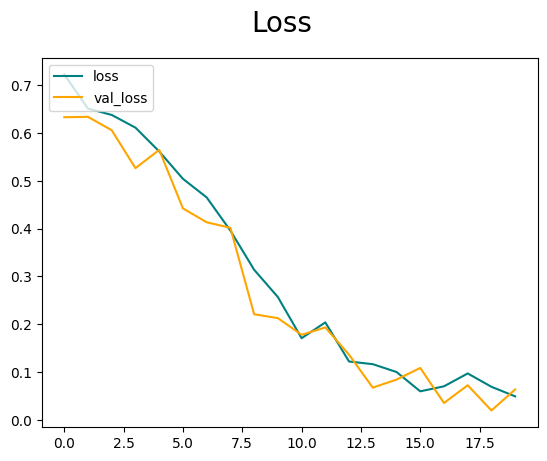

In [38]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc='upper left')
plt.show()

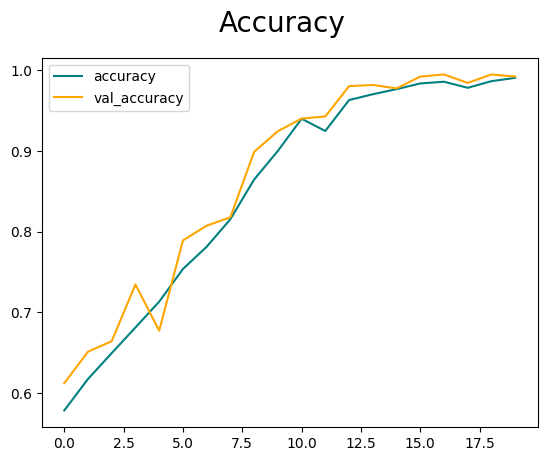

In [39]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc='upper left')
plt.show()

# 4.0 Performance Evaluation

### 4.1 Evaluate

In [40]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [41]:
precision = Precision()
recall = Recall()
accuracy = BinaryAccuracy()

In [42]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    precision.update_state(y, yhat)
    recall.update_state(y, yhat)
    accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


In [43]:
print(f'Precision : {precision.result().numpy()}, Recall : {recall.result().numpy()},Accuracy : {accuracy.result().numpy()}')

Precision : 1.0, Recall : 0.991304337978363,Accuracy : 0.9955357313156128


### 4.2 Test

Happy testing

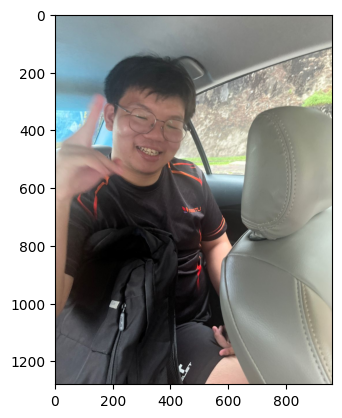

In [ ]:
img = cv.imread('happyTest5.jpg')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

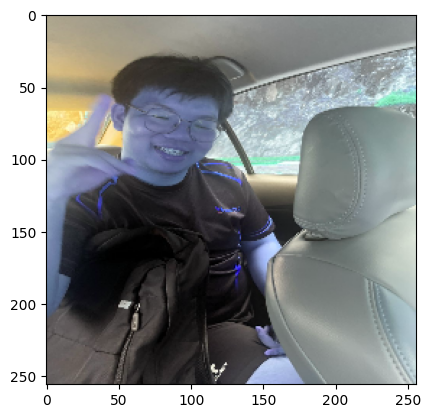

In [55]:
resized = tf.image.resize(img, (256,256))
plt.imshow(resized.numpy().astype(int))
plt.show()

In [ ]:
yhat = model.predict(np.expand_dims(resized/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [57]:
yhat

array([[0.10579693]], dtype=float32)

In [58]:
if yhat > 0.5:
    print("sad")
else:
    print("happy")

happy


Sad testing

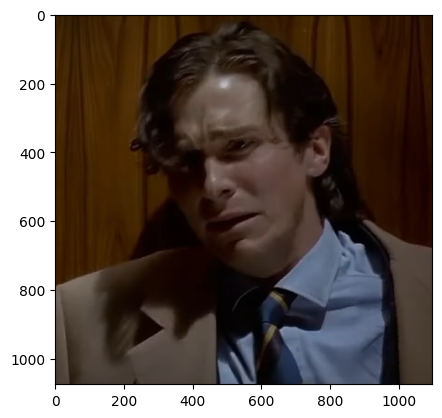

In [61]:
img = cv.imread('sadtest4.png')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

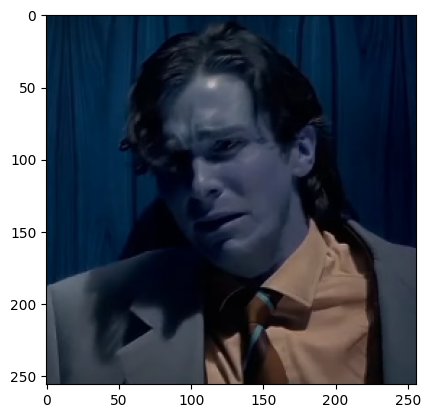

In [62]:
resized = tf.image.resize(img, (256,256))
plt.imshow(resized.numpy().astype(int))
plt.show()

In [63]:
yhat = model.predict(np.expand_dims(resized/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


In [64]:
yhat

array([[0.99988467]], dtype=float32)

In [65]:
if yhat > 0.5:
    print("sad")
else:
    print("happy")

sad


# 5.0 Save the model

In [49]:
from tensorflow.keras.models import load_model

In [50]:
model.save(os.path.join('models', 'emotionmodel.h5'))

In [51]:
new_model = load_model(os.path.join('models', 'emotionmodel.h5'))

In [52]:
yhat_new = new_model.predict(np.expand_dims(resized/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


In [53]:
if yhat_new > 0.5:
    print("sad")
else:
    print("happy")

sad
